# 含噪抛物映射相空间

本 notebook 模拟带弱过程噪声的二维抛物映射，并把相图整理成紧凑的论文图。该图用于检验：在存在随机扰动时，不同初值轨迹是否仍会收缩到吸引区域附近，同时在后期保留噪声主导的小幅波动。


## 图像设计目标

核心结论：弱过程噪声会扰动轨迹的后期路径，但从较宽初值网格出发的轨迹仍会收缩到较小的吸引区域。

图像类型：一个主相空间面板加两个紧凑验证面板的定量组合图。

绘图后端：仅使用 Python/matplotlib。最终输出面向双栏论文图，保留可编辑的 SVG/PDF 文本，并生成高分辨率栅格预览。

面板安排：a 面板展示相空间轨迹以及起点、终点标记；b 面板展示半径随迭代步数的衰减；c 面板比较终止半径与初始半径，用于说明不同初值下的收敛性。


## 实验配置

确定性映射为

$$x_{k+1}=\lambda x_k,\qquad y_{k+1}=\mu y_k+(\lambda^2-\mu)x_k^2,$$

随后在每一步确定性更新之后，对两个坐标分别加入小幅独立高斯噪声。


In [1]:
from pathlib import Path
import os
import sys
import tempfile

import numpy as np
import pandas as pd

repo_root = next(
    candidate
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "tools.py").exists()
)
module_dir = repo_root / "exp" / "analysitic"
fig_dir = module_dir / "figs"
fig_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "koopCEgis-mplconfig"))

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from tools import (
    compute_noisy_parabolic_observation_matrices,
    configure_noisy_parabolic_publication_style,
    make_initial_state_grid,
    plot_noisy_parabolic_observation_matrices,
    plot_noisy_parabolic_publication_figure,
    simulate_many_trajectories,
    summarize_noisy_parabolic_trajectories,
)

configure_noisy_parabolic_publication_style()

experiment_config = {
    "lam": 0.82,
    "mu": 0.45,
    "noise_scale": 0.015,
    "steps": 90,
    "seed": 20260505,
    "x_values": np.linspace(-1.2, 1.2, 3),
    "y_values": np.linspace(-0.65, 0.65, 3),
}

plot_config = {
    "figsize": (7.20, 4.15),
    "phase_output_base": fig_dir / "noisy_parabolic_map_phase_space",
    "matrix_output_base": fig_dir / "noisy_parabolic_observation_matrices",
    "formats": ("svg", "pdf", "png", "tiff"),
}

experiment_config

{'lam': 0.82,
 'mu': 0.45,
 'noise_scale': 0.015,
 'steps': 90,
 'seed': 20260505,
 'x_values': array([-1.2,  0. ,  1.2]),
 'y_values': array([-0.65,  0.  ,  0.65])}

## 轨迹模拟

生成初始条件网格，并用可复现的独立噪声流模拟每条轨迹。


In [2]:
initial_states = make_initial_state_grid(
    x_values=experiment_config["x_values"],
    y_values=experiment_config["y_values"],
)
trajectories = simulate_many_trajectories(
    initial_states=initial_states,
    steps=experiment_config["steps"],
    lam=experiment_config["lam"],
    mu=experiment_config["mu"],
    noise_scale=experiment_config["noise_scale"],
    seed=experiment_config["seed"],
)
summary = summarize_noisy_parabolic_trajectories(
    trajectories=trajectories,
    initial_states=initial_states,
)
summary.round(4)

,initial_x,initial_y,initial_radius,final_x,final_y,max_radius,final_radius
0,-1.2,-0.65,1.3647,-0.0153,0.0077,1.3647,0.0171
1,0.0,-0.65,0.6500,0.0060,-0.0246,0.6500,0.0253
2,1.2,-0.65,1.3647,-0.0289,0.0133,1.3647,0.0319
3,-1.2,0.00,1.2000,-0.0053,0.0022,1.2000,0.0057
4,0.0,0.00,0.0000,-0.0096,-0.0174,0.0779,0.0199
5,1.2,0.00,1.2000,-0.0520,0.0201,1.2000,0.0557
6,-1.2,0.65,1.3647,0.0317,-0.0112,1.3647,0.0336
7,0.0,0.65,0.6500,-0.0502,-0.0013,0.6500,0.0502
8,1.2,0.65,1.3647,0.0319,0.0189,1.3647,0.0371


## 半径统计

为了更直接地检查收缩结论，这里同时报告终止半径和每条轨迹达到过的最大半径。


In [3]:
summary[["initial_radius", "max_radius", "final_radius"]].describe().round(4)

,initial_radius,max_radius,final_radius
count,9.0000,9.0000,9.0000
mean,1.0177,1.0263,0.0307
std,0.4814,0.4611,0.0159
min,0.0000,0.0779,0.0057
25%,0.6500,0.6500,0.0199
50%,1.2000,1.2000,0.0319
75%,1.3647,1.3647,0.0371
max,1.3647,1.3647,0.0557


## 观测空间矩阵

观测向量设为 $\boldsymbol{\psi}=[x, y, x^2]^\top$。矩阵 $\boldsymbol{A}$ 是该观测空间中的解析一步映射矩阵，协方差矩阵 $\boldsymbol{\Sigma}$ 则由全部模拟观测样本估计得到。下图给出 $\boldsymbol{A}$ 与 $\boldsymbol{\Sigma}$ 的热图，便于检查提升坐标之间的耦合强度。

![观测空间映射矩阵与协方差矩阵](./figs/noisy_parabolic_observation_matrices.png)


svg     exp/analysitic/figs/noisy_parabolic_observatio...
pdf     exp/analysitic/figs/noisy_parabolic_observatio...
png     exp/analysitic/figs/noisy_parabolic_observatio...
tiff    exp/analysitic/figs/noisy_parabolic_observatio...
Name: matrix_outputs, dtype: object

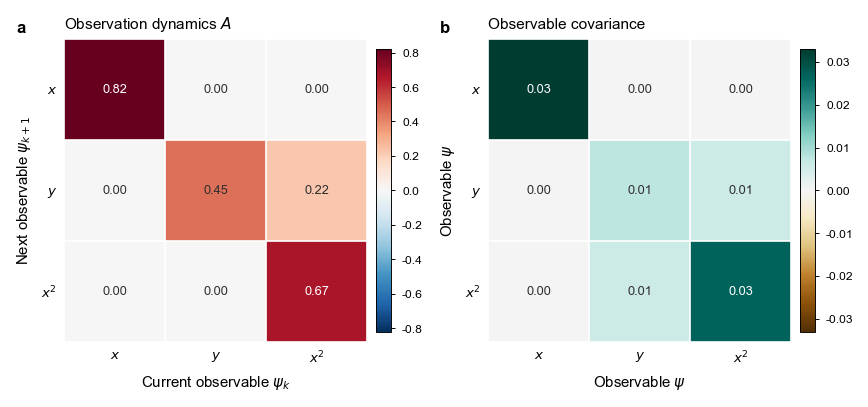

In [4]:
observation_matrices = compute_noisy_parabolic_observation_matrices(
    trajectories=trajectories,
    lam=experiment_config["lam"],
    mu=experiment_config["mu"],
)
fig_matrices, matrix_axes, matrix_outputs = plot_noisy_parabolic_observation_matrices(
    A=observation_matrices["A"],
    covariance=observation_matrices["covariance"],
    feature_names=observation_matrices["feature_names"],
    output_base=plot_config["matrix_output_base"],
    formats=plot_config["formats"],
)

pd.Series({key: str(path.relative_to(repo_root)) for key, path in matrix_outputs.items()}, name="matrix_outputs")

## 论文图

相空间面板使用颜色编码初始半径，并把标记图例放在坐标轴外侧；两个半径面板不重复标注每条轨迹，因此不会让图例遮挡数据。下图汇总了相图、半径衰减和终止半径对比。

![含噪抛物映射相空间与半径收缩](./figs/noisy_parabolic_map_phase_space.png)


svg     exp/analysitic/figs/noisy_parabolic_map_phase_...
pdf     exp/analysitic/figs/noisy_parabolic_map_phase_...
png     exp/analysitic/figs/noisy_parabolic_map_phase_...
tiff    exp/analysitic/figs/noisy_parabolic_map_phase_...
Name: saved_outputs, dtype: object

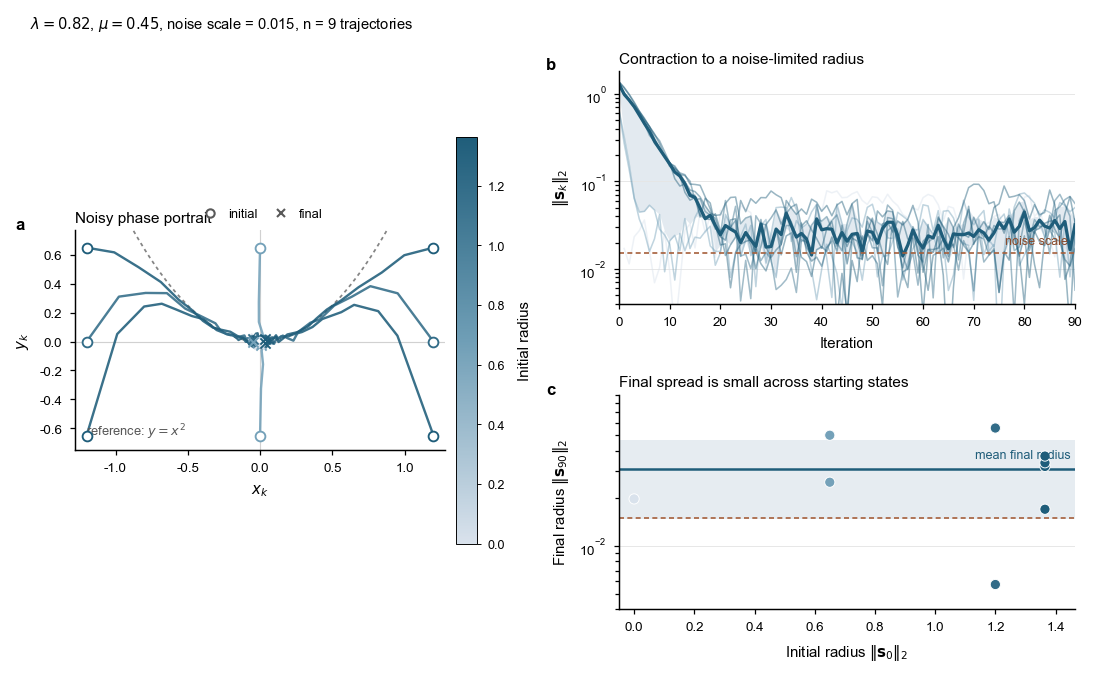

In [5]:
fig, axes, saved_outputs = plot_noisy_parabolic_publication_figure(
    trajectories=trajectories,
    initial_states=initial_states,
    lam=experiment_config["lam"],
    mu=experiment_config["mu"],
    noise_scale=experiment_config["noise_scale"],
    output_base=plot_config["phase_output_base"],
    formats=plot_config["formats"],
    figsize=plot_config["figsize"],
)

pd.Series({key: str(path.relative_to(repo_root)) for key, path in saved_outputs.items()}, name="saved_outputs")

## 结果解读

主相空间面板显示，在弱过程噪声下，确定性抛物结构仍然保持可辨识的几何形态。对数半径面板说明轨迹会从初始网格快速收缩到一个由噪声限制的窄带；终止半径面板进一步显示，在测试的不同起点下，后期散布仍保持在较小范围内。

在观测空间中，$\boldsymbol{A}$ 的热图揭示了 $\boldsymbol{\psi}=[x, y, x^2]^\top$ 在抛物映射下的三角依赖关系。$\boldsymbol{\Sigma}$ 的热图显示哪些提升坐标主导了采样观测云，以及交叉协方差是否会影响后续 Koopman 分析或粗粒化分析。

需要注意的是，这组图目前只覆盖一个随机种子、一组参数和一个噪声尺度。后续稳健性检查应扫描 `noise_scale`、`lambda` 和 `mu`，以识别含噪相图发生定性变化的参数区域。


<!-- backward-svd-two-group-experiment -->
## 反向 SVD 双组实验

本节展示由 `plot_backward_svd_parameter_grid.py` 生成的两组后续参数网格。两张图都采用相同的三行结构：相空间轨迹、$\boldsymbol{A}^\top \boldsymbol{\Sigma}^{-1}\boldsymbol{A}$ 的奇异值，以及特征 $\boldsymbol{\psi}=[x, y, x^2]^\top$ 上的左奇异向量载荷。

第二组实验的轨迹差异主要由过程噪声控制。下面代码单元中的 `backward_svd_noise_process_max` 是手动可调的最大过程噪声；调大该值并重新运行该单元，即可生成新的噪声扫描图和汇总表。



In [6]:
from IPython.display import Image, display
import subprocess

# 手动调节这里：数值越大，Group 2 中最高噪声轨迹的随机波动越明显。
backward_svd_noise_process_max = 0.2

svd_outputs = {
    "deterministic_png": fig_dir / "backward_svd_parameter_grid_deterministic.png",
    "deterministic_summary": fig_dir / "backward_svd_parameter_grid_deterministic_summary.csv",
    "noise_png": fig_dir / "backward_svd_parameter_grid_noise.png",
    "noise_summary": fig_dir / "backward_svd_parameter_grid_noise_summary.csv",
}

missing = [key for key, path in svd_outputs.items() if not path.exists()]
stale_noise_scan = True
if svd_outputs["noise_summary"].exists():
    previous_noise_summary = pd.read_csv(svd_outputs["noise_summary"])
    previous_max_process_noise = float(previous_noise_summary["process_noise"].max())
    stale_noise_scan = not np.isclose(previous_max_process_noise, backward_svd_noise_process_max)

if missing or stale_noise_scan:
    subprocess.run(
        [
            sys.executable,
            str(module_dir / "plot_backward_svd_parameter_grid.py"),
            "--formats",
            "png",
            "svg",
            "--noise-process-max",
            str(backward_svd_noise_process_max),
        ],
        cwd=repo_root,
        check=True,
    )
    missing = [key for key, path in svd_outputs.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing SVD output files after regeneration: {missing}")

pd.Series(
    {
        "noise_process_max": backward_svd_noise_process_max,
        **{key: str(path.relative_to(repo_root)) for key, path in svd_outputs.items()},
    },
    name="svd_outputs",
)


noise_process_max                                                      0.2
deterministic_png        exp/analysitic/figs/backward_svd_parameter_gri...
deterministic_summary    exp/analysitic/figs/backward_svd_parameter_gri...
noise_png                exp/analysitic/figs/backward_svd_parameter_gri...
noise_summary            exp/analysitic/figs/backward_svd_parameter_gri...
Name: svd_outputs, dtype: object

### 第一组：固定弱噪声，改变确定性动力学

噪声固定为 $a=0.02$、$b=0.00$，过程噪声尺度保持很弱。确定性参数从 $x$ 方向快速消失的情形，逐步移动到 $x$、$y$ 和 $x^2$ 都能在动力学中保持可见的情形。

![固定弱噪声下的确定性动力学扫描](./figs/backward_svd_parameter_grid_deterministic.png)


In [7]:
deterministic_summary = pd.read_csv(svd_outputs["deterministic_summary"])
deterministic_summary[ [
    "combo", "lambda", "mu", "sigma_a", "sigma_b", "process_noise", "sv1", "sv2", "sv3"
] ].round(6)


,combo,lambda,mu,sigma_a,sigma_b,process_noise,sv1,sv2,sv3
0,D1,0.10,0.90,0.02,0.0,0.0002,80.107471,0.500000,0.002528
1,D2,0.25,0.88,0.02,0.0,0.0002,72.225918,3.125000,0.104706
2,D3,0.45,0.84,0.02,0.0,0.0002,56.367346,10.125000,1.283279
3,D4,0.65,0.82,0.02,0.0,0.0002,43.556422,21.125000,6.889202
4,D5,0.82,0.80,0.02,0.0,0.0002,34.377483,33.620000,21.042692
5,D6,0.95,0.78,0.02,0.0,0.0002,45.125000,43.254057,28.641567


数值来源表：

| 组合 | lambda | mu | sigma_a | sigma_b | process_noise | sv1 | sv2 | sv3 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| D1 | 0.1 | 0.9 | 0.02 | 0 | 0.0002 | 80.11 | 0.5 | 0.002528 |
| D2 | 0.25 | 0.88 | 0.02 | 0 | 0.0002 | 72.23 | 3.125 | 0.1047 |
| D3 | 0.45 | 0.84 | 0.02 | 0 | 0.0002 | 56.37 | 10.12 | 1.283 |
| D4 | 0.65 | 0.82 | 0.02 | 0 | 0.0002 | 43.56 | 21.12 | 6.889 |
| D5 | 0.82 | 0.8 | 0.02 | 0 | 0.0002 | 34.38 | 33.62 | 21.04 |
| D6 | 0.95 | 0.78 | 0.02 | 0 | 0.0002 | 45.12 | 43.25 | 28.64 |

比值 $s_1/s_2$ 从 D1 的约 `160` 降到 D5-D6 的约 `1`。这是预期的机制检查：当不再存在某个观测方向明显快于其他方向消失时，奇异值谱也不再支持清晰的一维截断。


### 第二组：固定快慢动力学，改变噪声强度

确定性动力学固定为 $\lambda=0.10$、$\mu=0.90$，从而保留快慢分离。噪声协方差矩阵保持相同结构，即 $(\boldsymbol{\Sigma})_{xx}=(\boldsymbol{\Sigma})_{yy}=(\boldsymbol{\Sigma})_{x^2x^2}=a$ 且 $(\boldsymbol{\Sigma})_{x,x^2}=b=0.2a$，同时逐步增大整体噪声强度。过程噪声采用从 `0.0002` 到 `backward_svd_noise_process_max` 的几何间隔，因此调大最大值后，高噪声列的轨迹扰动会更明显。

![固定动力学下的噪声强度扫描](./figs/backward_svd_parameter_grid_noise.png)


In [8]:
noise_summary = pd.read_csv(svd_outputs["noise_summary"])
noise_summary[ [
    "combo", "lambda", "mu", "sigma_a", "sigma_b", "process_noise", "sv1", "sv2", "sv3"
] ].round(6)


,combo,lambda,mu,sigma_a,sigma_b,process_noise,sv1,sv2,sv3
0,N1,0.1,0.9,0.02,0.004,0.000200,80.107575,0.520938,0.002527
1,N2,0.1,0.9,0.05,0.010,0.000796,32.043030,0.208375,0.001011
2,N3,0.1,0.9,0.10,0.020,0.003170,16.021515,0.104188,0.000505
3,N4,0.1,0.9,0.20,0.040,0.012619,8.010758,0.052094,0.000253
4,N5,0.1,0.9,0.50,0.100,0.050238,3.204303,0.020838,0.000101
5,N6,0.1,0.9,1.00,0.200,0.200000,1.602152,0.010419,0.000051


上方代码单元会从当前生成的 `backward_svd_parameter_grid_noise_summary.csv` 读取数值来源表，因此当 `backward_svd_noise_process_max` 被手动调大或调小时，表格会随重新生成的 CSV 自动更新。

在当前默认设置下，过程噪声从 `0.0002` 按几何间隔增加到 `0.2`。随着噪声增强，奇异值谱主要表现为整体向下缩放，而奇异向量热图几乎保持不变；同时，高噪声列的相空间轨迹已经出现明显随机摆动。因此这张图现在能同时展示固定快慢结构下的谱缩放，以及过程噪声对轨迹形态的可见扰动。
